# Clasificador de Razas de Perros

En este proyecto vamos a entrenar un modelo de deep learning que sea capaz de identificar la raza de un perro a partir de una foto. Para esto usamos el Stanford Dogs Dataset que tiene 120 razas distintas.


---
## Etapa 1 - Instalar librerías


In [ ]:
# instalamos las librerías principales


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import tarfile
import json
import random
from PIL import Image
from sklearn.model_selection import train_test_split


TensorFlow version: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Etapa 2 - Descargar y descomprimir el dataset

El dataset de Stanford tiene imágenes de 120 razas de perros. Pesa alrededor de 750 MB así que la descarga puede tardar un poco dependiendo de la conexión. Lo guardamos en una carpeta y lo descomprimimos.

In [2]:
# descargamos el dataset desde la página oficial de Stanford
!wget -q --show-progress -O /content/images.tar http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
print("Descarga lista")

/content/images.tar 100%[===================>] 756.82M  56.7MB/s    in 15s     
Descarga lista


In [3]:
# descomprimimos el archivo .tar
with tarfile.open('/content/images.tar', 'r') as tar:
    tar.extractall('/content/')

# vemos cuántas carpetas (razas) hay
razas = sorted(os.listdir('/content/Images'))
print("Total de razas:", len(razas))
print("Primeras 5 razas:", razas[:5])

/tmp/ipykernel_13873/2949315396.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content/')


Total de razas: 120
Primeras 5 razas: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


---
## Etapa 3 - Organizar las imágenes en carpetas de entrenamiento y validación

Keras necesita que las imágenes estén organizadas en carpetas: una carpeta para entrenamiento y otra para validación. Dentro de cada una, debe haber una subcarpeta por cada raza.

Vamos a usar el 80% de las imágenes para entrenar y el 20% restante para validar.

In [4]:
# creamos las carpetas de destino
os.makedirs('/content/dataset/train', exist_ok=True)
os.makedirs('/content/dataset/val', exist_ok=True)

nombres_razas = []

# recorremos cada carpeta de raza y dividimos las imágenes
for carpeta in razas:
    ruta_raza = os.path.join('/content/Images', carpeta)

    # limpiamos el nombre: 'n02085620-Chihuahua' -> 'Chihuahua'
    nombre_limpio = carpeta.split('-', 1)[-1]
    nombres_razas.append(nombre_limpio)

    imagenes = os.listdir(ruta_raza)

    # dividimos 80% train, 20% val
    train_imgs, val_imgs = train_test_split(imagenes, test_size=0.2, random_state=42)

    # copiamos las imágenes a sus carpetas correspondientes
    for split, lista in [('train', train_imgs), ('val', val_imgs)]:
        destino = os.path.join('/content/dataset', split, nombre_limpio)
        os.makedirs(destino, exist_ok=True)
        for img in lista:
            shutil.copy(os.path.join(ruta_raza, img), os.path.join(destino, img))

# guardamos los nombres de razas en un archivo para usarlo en la app
with open('/content/class_names.json', 'w') as f:
    json.dump(nombres_razas, f)

print("Dataset organizado correctamente")
print("Imágenes de entrenamiento:", sum([len(os.listdir(f'/content/dataset/train/{r}')) for r in os.listdir('/content/dataset/train')]))
print("Imágenes de validación:", sum([len(os.listdir(f'/content/dataset/val/{r}')) for r in os.listdir('/content/dataset/val')]))

Dataset organizado correctamente
Imágenes de entrenamiento: 16418
Imágenes de validación: 4162


---
## Etapa 4 - Ver algunas imágenes del dataset

Antes de entrenar, es buena práctica ver cómo se ven las imágenes para entender con qué datos estamos trabajando.

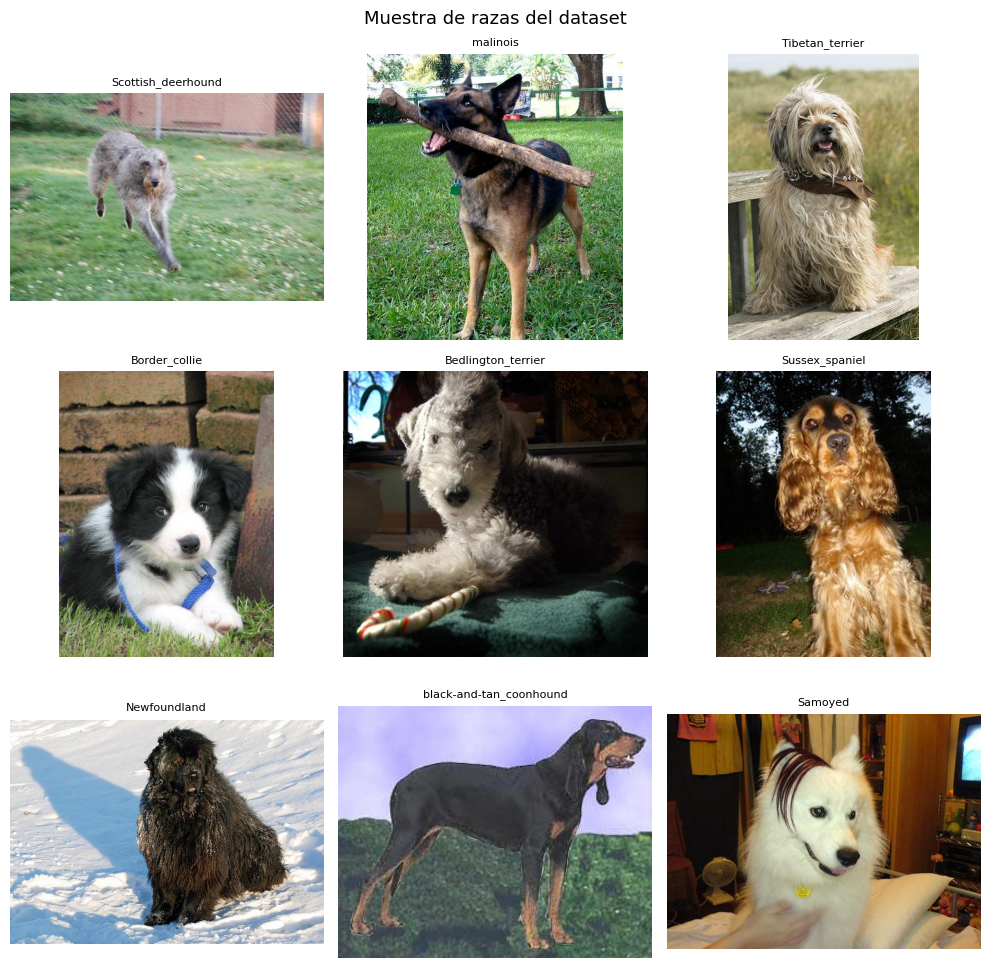

In [5]:
# mostramos una imagen de ejemplo de 9 razas distintas
razas_muestra = random.sample(os.listdir('/content/dataset/train'), 9)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, raza in enumerate(razas_muestra):
    ruta = f'/content/dataset/train/{raza}'
    imagen_nombre = os.listdir(ruta)[0]
    img = Image.open(os.path.join(ruta, imagen_nombre))
    axes[i].imshow(img)
    axes[i].set_title(raza, fontsize=8)
    axes[i].axis('off')

plt.suptitle('Muestra de razas del dataset', fontsize=13)
plt.tight_layout()
plt.show()

---
## Etapa 5 - Preprocesar las imágenes con ImageDataGenerator

Usamos `ImageDataGenerator` de Keras para cargar las imágenes en lotes (batches). También aplicamos data augmentation en el conjunto de entrenamiento: esto básicamente le enseña al modelo a reconocer razas aunque la foto esté un poco rotada, con zoom o volteada.

Las imágenes se redimensionan a 224x224 píxeles que es el tamaño que necesita el modelo que vamos a usar.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# generador para entrenamiento CON augmentación
train_gen = ImageDataGenerator(
    rescale=1./255,          # normaliza los pixeles de 0-255 a 0-1
    rotation_range=20,       # rota las imágenes un poco
    horizontal_flip=True,    # voltea la imagen horizontalmente
    zoom_range=0.2           # aplica zoom aleatorio
)

# generador para validación SIN augmentación (solo normalizamos)
val_gen = ImageDataGenerator(rescale=1./255)

# cargamos las imágenes desde las carpetas
train_data = train_gen.flow_from_directory(
    '/content/dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    '/content/dataset/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

NUM_CLASSES = len(train_data.class_indices)
print("Número de clases:", NUM_CLASSES)

# guardamos el orden de clases del generador (puede ser diferente al de nombres_razas)
clases_ordenadas = [None] * NUM_CLASSES
for nombre, idx in train_data.class_indices.items():
    clases_ordenadas[idx] = nombre

with open('/content/class_names.json', 'w') as f:
    json.dump(clases_ordenadas, f)
print("Archivo class_names.json actualizado")

Found 16418 images belonging to 120 classes.
Found 4162 images belonging to 120 classes.
Número de clases: 120
Archivo class_names.json actualizado


---
## Etapa 6 - Construir el modelo con Transfer Learning

En lugar de entrenar una red desde cero (lo cual requeriría muchos más datos y tiempo), usamos Transfer Learning. Esto consiste en tomar un modelo que ya fue entrenado con millones de imágenes (MobileNetV2 entrenado en ImageNet) y adaptarlo a nuestro problema.

La idea es:
1. Usamos MobileNetV2 como base para extraer características de las imágenes
2. Le agregamos nuestras propias capas al final para clasificar las 120 razas
3. Primero entrenamos solo las capas nuevas (la base se queda congelada)

MobileNetV2 es un modelo liviano que funciona bien y es rápido de entrenar.

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# cargamos MobileNetV2 sin la capa de clasificación final
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,       # quitamos la última capa de imagenet
    weights='imagenet'       # usamos los pesos preentrenados
)

# congelamos la base para no modificar sus pesos
base_model.trainable = False

# construimos nuestro modelo encima de la base
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   # reduce las features a un vector
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),               # dropout para evitar overfitting
    layers.Dense(NUM_CLASSES, activation='softmax')  # capa de salida con 120 razas
])

# compilamos el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │        30,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,616,760 (9.98 MB)

 Trainable params: 358,776 (1.37 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## Etapa 7 - Entrenar el modelo

Ahora sí entrenamos. Usamos 10 épocas para la primera fase donde la base está congelada. Guardamos también el mejor modelo encontrado durante el entrenamiento usando un ModelCheckpoint.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# guardamos el mejor modelo durante el entrenamiento
checkpoint = ModelCheckpoint(
    '/content/modelo_perros.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# detenemos el entrenamiento si no mejora en 4 épocas seguidas
early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

print("Entrenando modelo...")
historial = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[checkpoint, early_stop]
)

print("Entrenamiento terminado")

Entrenando modelo...
Epoch 1/10
112/514 ━━━━━━━━━━━━━━━━━━━━ 2:27 368ms/step - accuracy: 0.1128 - loss: 4.3046

---
## Etapa 8 - Ver las curvas de entrenamiento

Graficamos la accuracy y el loss a lo largo de las épocas para ver si el modelo aprendió correctamente. Lo ideal es que la curva de entrenamiento y la de validación vayan juntas (sin mucha diferencia entre ellas).

In [ ]:
# graficamos accuracy y loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historial.history['accuracy'], label='Entrenamiento')
ax1.plot(historial.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(historial.history['loss'], label='Entrenamiento')
ax2.plot(historial.history['val_loss'], label='Validación')
ax2.set_title('Loss por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

---
## Etapa 9 - Evaluar el modelo con las imágenes de validación

Evaluamos el modelo final sobre el conjunto de validación para ver qué tan bien le fue.

In [ ]:
# evaluamos el modelo con los datos de validación
loss, accuracy = model.evaluate(val_data)
print(f"Loss en validación: {loss:.4f}")
print(f"Accuracy en validación: {accuracy*100:.2f}%")

---
## Etapa 10 - Probar el modelo con una imagen nueva

Hacemos una prueba rápida de predicción con una imagen del dataset para ver cómo responde el modelo. Esta misma lógica es la que va a usar la aplicación de Streamlit.

In [ ]:
# cargamos el modelo guardado
modelo_cargado = tf.keras.models.load_model('/content/modelo_perros.keras')

# cargamos los nombres de razas
with open('/content/class_names.json') as f:
    nombres = json.load(f)

# tomamos una imagen cualquiera del set de validación para probar
raza_prueba = random.choice(os.listdir('/content/dataset/val'))
ruta_prueba = f'/content/dataset/val/{raza_prueba}'
imagen_prueba = random.choice(os.listdir(ruta_prueba))
ruta_imagen = os.path.join(ruta_prueba, imagen_prueba)

# preprocesamos la imagen igual que en el entrenamiento
img = Image.open(ruta_imagen).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # agregamos dimensión de batch

# hacemos la predicción
prediccion = modelo_cargado.predict(img_array)[0]

# obtenemos el top 5 de razas más probables
top5_indices = np.argsort(prediccion)[::-1][:5]
top5 = [(nombres[i], prediccion[i]*100) for i in top5_indices]

# mostramos la imagen y las predicciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(img)
ax1.set_title(f'Raza real: {raza_prueba}', fontsize=9)
ax1.axis('off')

razas_grafico = [t[0] for t in top5]
probs_grafico = [t[1] for t in top5]
ax2.barh(razas_grafico[::-1], probs_grafico[::-1], color='steelblue')
ax2.set_xlabel('Probabilidad (%)')
ax2.set_title('Top 5 predicciones')

plt.tight_layout()
plt.show()

print("Predicción principal:", top5[0][0], f"({top5[0][1]:.1f}%)")

---
## Etapa 11 - Descargar los archivos del modelo

Descargamos el modelo entrenado y el archivo con los nombres de razas para subirlos a GitHub y usarlos en la app de Streamlit.

In [ ]:
# descargamos los archivos necesarios para la app
from google.colab import files

files.download('/content/modelo_perros.keras')
files.download('/content/class_names.json')

print("Archivos descargados")